# Central Limit Theorem (CLT) — Demo

This notebook demonstrates the **Central Limit Theorem** using simulation.

We will:
- Create a non-Normal population.
- Draw many random samples.
- Calculate the mean of each sample.
- Visualize the sampling distribution.
- Observe how increasing sample size makes the sampling distribution approximately Normal.
- Verify $\mu_{\bar{x}} = \mu$ and $\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Create a Non-Normal Population

We use an **exponential distribution**, which is strongly right-skewed and therefore not Normally Distributed.

In [2]:
population = np.random.exponential(scale=2, size=100_000)

population_mean = population.mean()
population_std = population.std()

print(f"Population Mean: {population_mean:.3f}")
print(f"Population Standard Deviation: {population_std:.3f}")

Population Mean: 1.992
Population Standard Deviation: 1.986


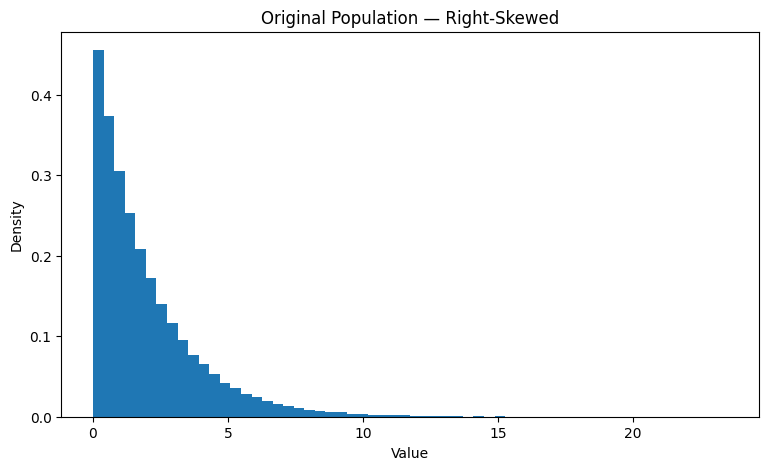

In [3]:
plt.figure(figsize=(9, 5))
plt.hist(population, bins=60, density=True)
plt.title("Original Population — Right-Skewed")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

## 2. Sampling Distribution for $n = 5$

Take many samples of size 5 and calculate their means. The original population is not Normal, so the sampling distribution is still influenced by its skewness.

In [4]:
n = 5
num_samples = 10_000

samples = np.random.choice(population, size=(num_samples, n), replace=True)
sample_means = samples.mean(axis=1)

print(f"Mean of sample means: {sample_means.mean():.3f}")
print(f"Standard deviation of sample means: {sample_means.std():.3f}")
print(f"Theoretical SEM: {population_std / np.sqrt(n):.3f}")

Mean of sample means: 2.012
Standard deviation of sample means: 0.889
Theoretical SEM: 0.888


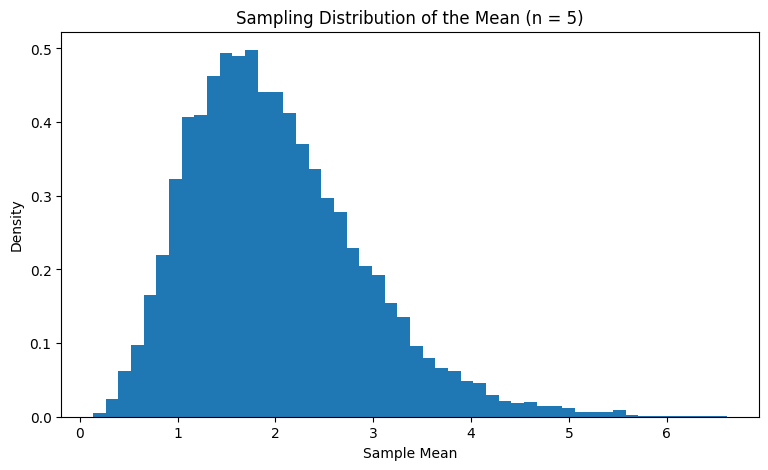

In [5]:
plt.figure(figsize=(9, 5))
plt.hist(sample_means, bins=50, density=True)
plt.title("Sampling Distribution of the Mean (n = 5)")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.show()

## 3. Sampling Distribution for $n = 30$

A common practical rule of thumb is $n \geq 30$ for a non-Normal population, although this is **not an absolute requirement**. The required sample size depends on the population's shape and variability.

In [6]:
n = 30

samples = np.random.choice(population, size=(num_samples, n), replace=True)
sample_means = samples.mean(axis=1)

print(f"Mean of sample means: {sample_means.mean():.3f}")
print(f"Theoretical population mean: {population_mean:.3f}")
print(f"Observed standard error: {sample_means.std():.3f}")
print(f"Theoretical SEM: {population_std / np.sqrt(n):.3f}")

Mean of sample means: 1.996
Theoretical population mean: 1.992
Observed standard error: 0.361
Theoretical SEM: 0.363


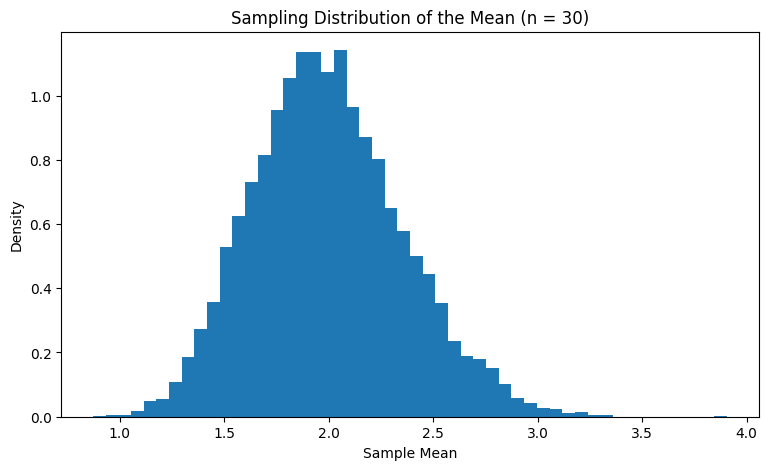

In [7]:
plt.figure(figsize=(9, 5))
plt.hist(sample_means, bins=50, density=True)
plt.title("Sampling Distribution of the Mean (n = 30)")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.show()

## 4. Effect of Increasing Sample Size

As $n$ increases, $\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$ decreases, so the sampling distribution becomes narrower and more concentrated around the population mean.

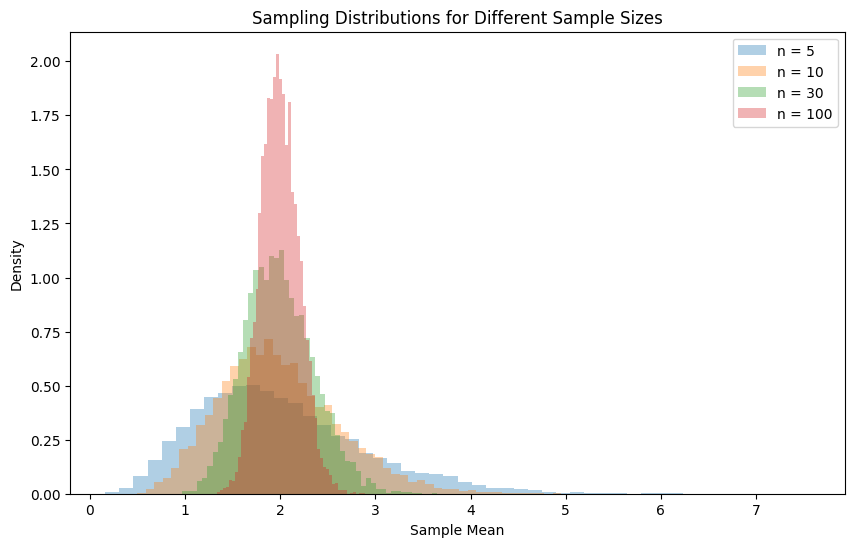

In [8]:
sample_sizes = [5, 10, 30, 100]

plt.figure(figsize=(10, 6))

for n in sample_sizes:
    samples = np.random.choice(population, size=(num_samples, n), replace=True)
    sample_means = samples.mean(axis=1)
    plt.hist(sample_means, bins=50, density=True, alpha=0.35, label=f"n = {n}")

plt.title("Sampling Distributions for Different Sample Sizes")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()
plt.show()

## 5. Verify the CLT Mean Relationship

The CLT gives $\mu_{\bar{x}} = \mu$. The mean of the sampling distribution should therefore be approximately equal to the population mean.

In [9]:
n = 50

samples = np.random.choice(population, size=(num_samples, n), replace=True)
sample_means = samples.mean(axis=1)

print(f"Population mean:      {population_mean:.4f}")
print(f"Mean of sample means: {sample_means.mean():.4f}")

Population mean:      1.9919
Mean of sample means: 1.9941


## 6. Verify the Standard Error Relationship

The theoretical standard deviation of the sampling distribution is $\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$.

In [10]:
observed_sem = sample_means.std()
theoretical_sem = population_std / np.sqrt(n)

print(f"Observed SEM:    {observed_sem:.4f}")
print(f"Theoretical SEM: {theoretical_sem:.4f}")

Observed SEM:    0.2767
Theoretical SEM: 0.2809


## 7. Final Observation

The simulation demonstrates the main idea of the Central Limit Theorem:

> The **sampling distribution of the sample mean** becomes approximately Normal as the sample size increases, even when the original population is not Normally Distributed.

Remember:
- CLT applies to the **sampling distribution**, not the original population.
- The center remains approximately at the population mean.
- Increasing $n$ reduces the standard error.
- $n \geq 30$ is a useful rule of thumb, not a universal guarantee.